In [1]:
import geopandas as gpd
import pandas as pd

basline_blocks = gpd.read_file('./data/gatchina/blocks_agg_with_indicators.geojson')
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,non_living_area,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,9195.928868,30.0,836277.821580,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,25627.346987,2000.0,420144.041613,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,19679.266138,2275.0,302985.560227,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,17349.402634,134.0,124546.982903,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,16945.739375,56.0,119574.990985,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."


In [2]:
cols = [
    'residential','business','recreation','industrial','transport','special',
    'agriculture','land_use','share','footprint_area','build_floor_area',
    'living_area','non_living_area','population','site_area','fsi','gsi',
    'mxi','l','morphotype','area_accessibility', 'geometry'
]
basline_blocks = basline_blocks[cols]


In [3]:
from catboost import CatBoostRegressor
model = CatBoostRegressor()
model.load_model('./data/catboost_land_value_no_services.cbm')  # модель на лог-цене
print(len(model.feature_names_))

101


In [4]:
feature_cols = [
'residential','business','recreation','industrial','transport','special',
'agriculture','land_use','share','footprint_area','build_floor_area',
'living_area','non_living_area','population','site_area','fsi','gsi',
'mxi','l','morphotype','area_accessibility'
]
cat_features = ['land_use', 'morphotype']
numeric_feats = [c for c in feature_cols if c not in cat_features]

In [5]:
basline_blocks['residential'] = basline_blocks['residential'].astype('float64')

In [6]:
# import geopandas as gpd
# import pandas as pd

# # 1. Переводим в метрическую CRS
# baseline_blocks_metric = basline_blocks.to_crs(basline_blocks.estimate_utm_crs()).copy()

# # 2. Считаем площадь в м2 и гектарах
# baseline_blocks_metric["calc_area_m2"] = baseline_blocks_metric.geometry.area
# baseline_blocks_metric["calc_area_ha"] = baseline_blocks_metric["calc_area_m2"] / 10_000

# # 3. Переводим site_area в гектары
# baseline_blocks_metric["site_area_ha"] = baseline_blocks_metric["site_area"] / 10_000

# # 4. Сравниваем
# baseline_blocks_metric["area_diff_ha"] = (
#     baseline_blocks_metric["calc_area_ha"] - baseline_blocks_metric["site_area_ha"]
# )

# baseline_blocks_metric["area_diff_pct"] = (
#     baseline_blocks_metric["area_diff_ha"] / baseline_blocks_metric["site_area_ha"] * 100
# )

# # 5. Сводка
# print(
#     baseline_blocks_metric[
#         ["site_area_ha", "calc_area_ha", "area_diff_ha", "area_diff_pct"]
#     ].describe()
# )

# # 6. Самые большие расхождения
# comparison_ha = baseline_blocks_metric[
#     ["site_area_ha", "calc_area_ha", "area_diff_ha", "area_diff_pct", "geometry"]
# ].copy()

# comparison_ha["abs_area_diff_pct"] = comparison_ha["area_diff_pct"].abs()
# comparison_ha.sort_values("abs_area_diff_pct", ascending=False).head(10)


In [7]:
# удаляем старую колонку
basline_blocks = basline_blocks.drop(columns=["site_area"], errors="ignore").copy()

# пересчитываем площадь в метрической CRS
basline_blocks_metric = basline_blocks.to_crs(basline_blocks.estimate_utm_crs()).copy()
basline_blocks["site_area"] = basline_blocks_metric.geometry.area.values


In [8]:

from urbanomy.methods.land_value_modeling import LandPriceEstimator

estimator = LandPriceEstimator(
    model=model,
    orig_features=numeric_feats+cat_features,
    categorical_features=cat_features,
    blocks=basline_blocks, #or blocks_198
)
blocks_pred = estimator.predict()
blocks_pred.head()


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,population,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry,site_area,land_value
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,30.0,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",215420.389645,4.523965e+08
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,2000.0,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",108166.972589,6.273598e+08
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,2275.0,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",77911.495727,5.809435e+08
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,134.0,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",32058.270586,1.065881e+08
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,56.0,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",30779.356283,8.802486e+07


count       333.000000
mean     362550.398065
std      166120.451087
min           0.000000
25%      192695.695235
50%      411948.014838
75%      501687.185946
max      642932.168889
Name: land_value_per_100m2, dtype: float64


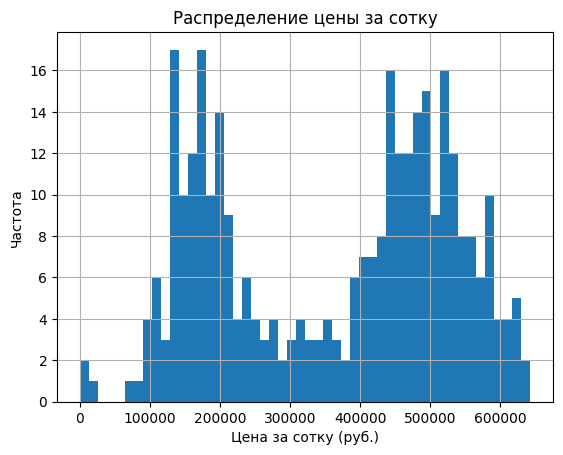

In [9]:
import numpy as np
import matplotlib.pyplot as plt
# 1) Цена за сотку (100 м²)
blocks_pred["land_value_per_100m2"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred = blocks_pred.replace([np.inf, -np.inf], np.nan)
blocks_pred = blocks_pred.fillna(0)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["land_value_per_100m2"].quantile(0.95)
blocks_clean = blocks_pred[blocks_pred["land_value_per_100m2"] <= p99].copy()

print(blocks_clean["land_value_per_100m2"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["land_value_per_100m2"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("Распределение цены за сотку")
plt.show()



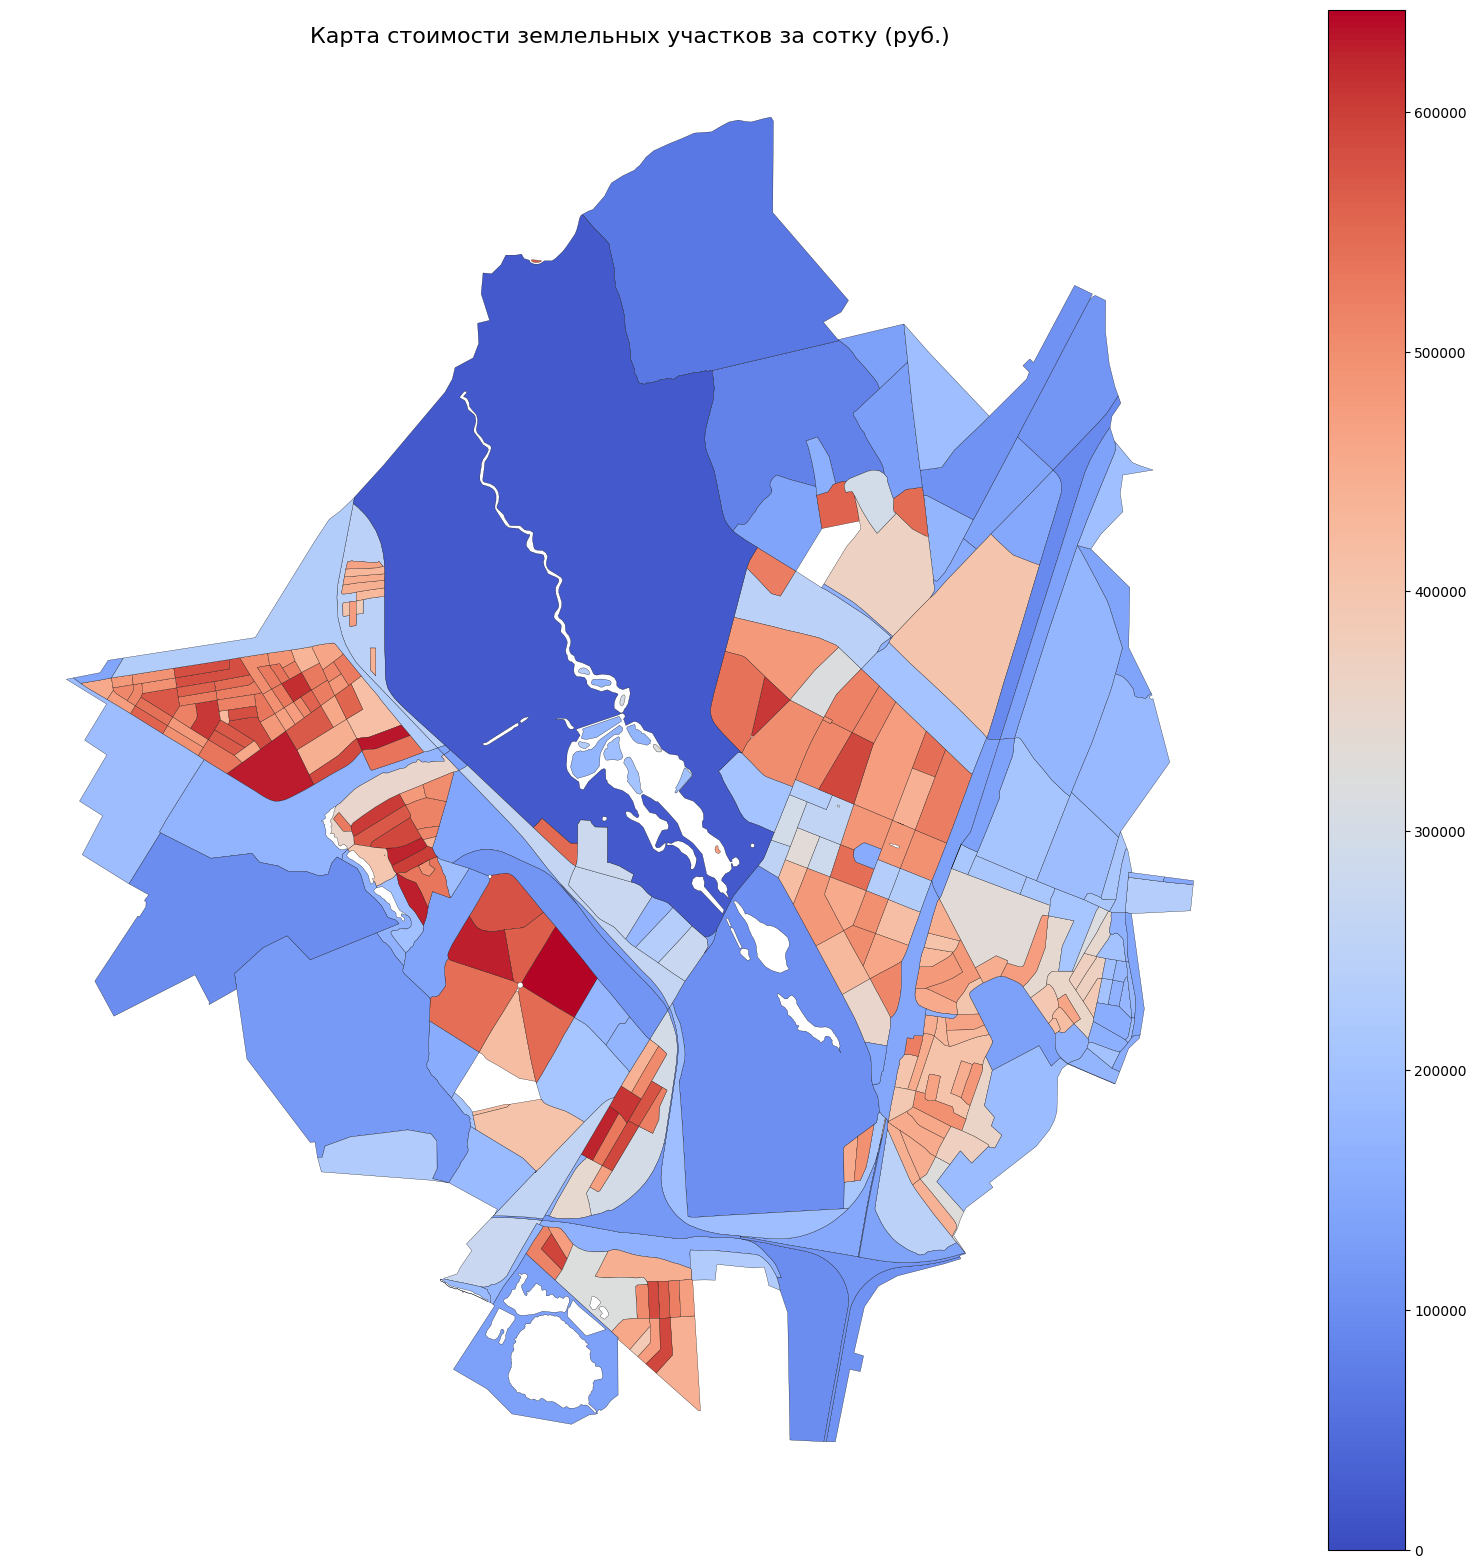

In [10]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value_per_100m2',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости землельных участков за сотку (руб.)', fontsize=16)

plt.show()

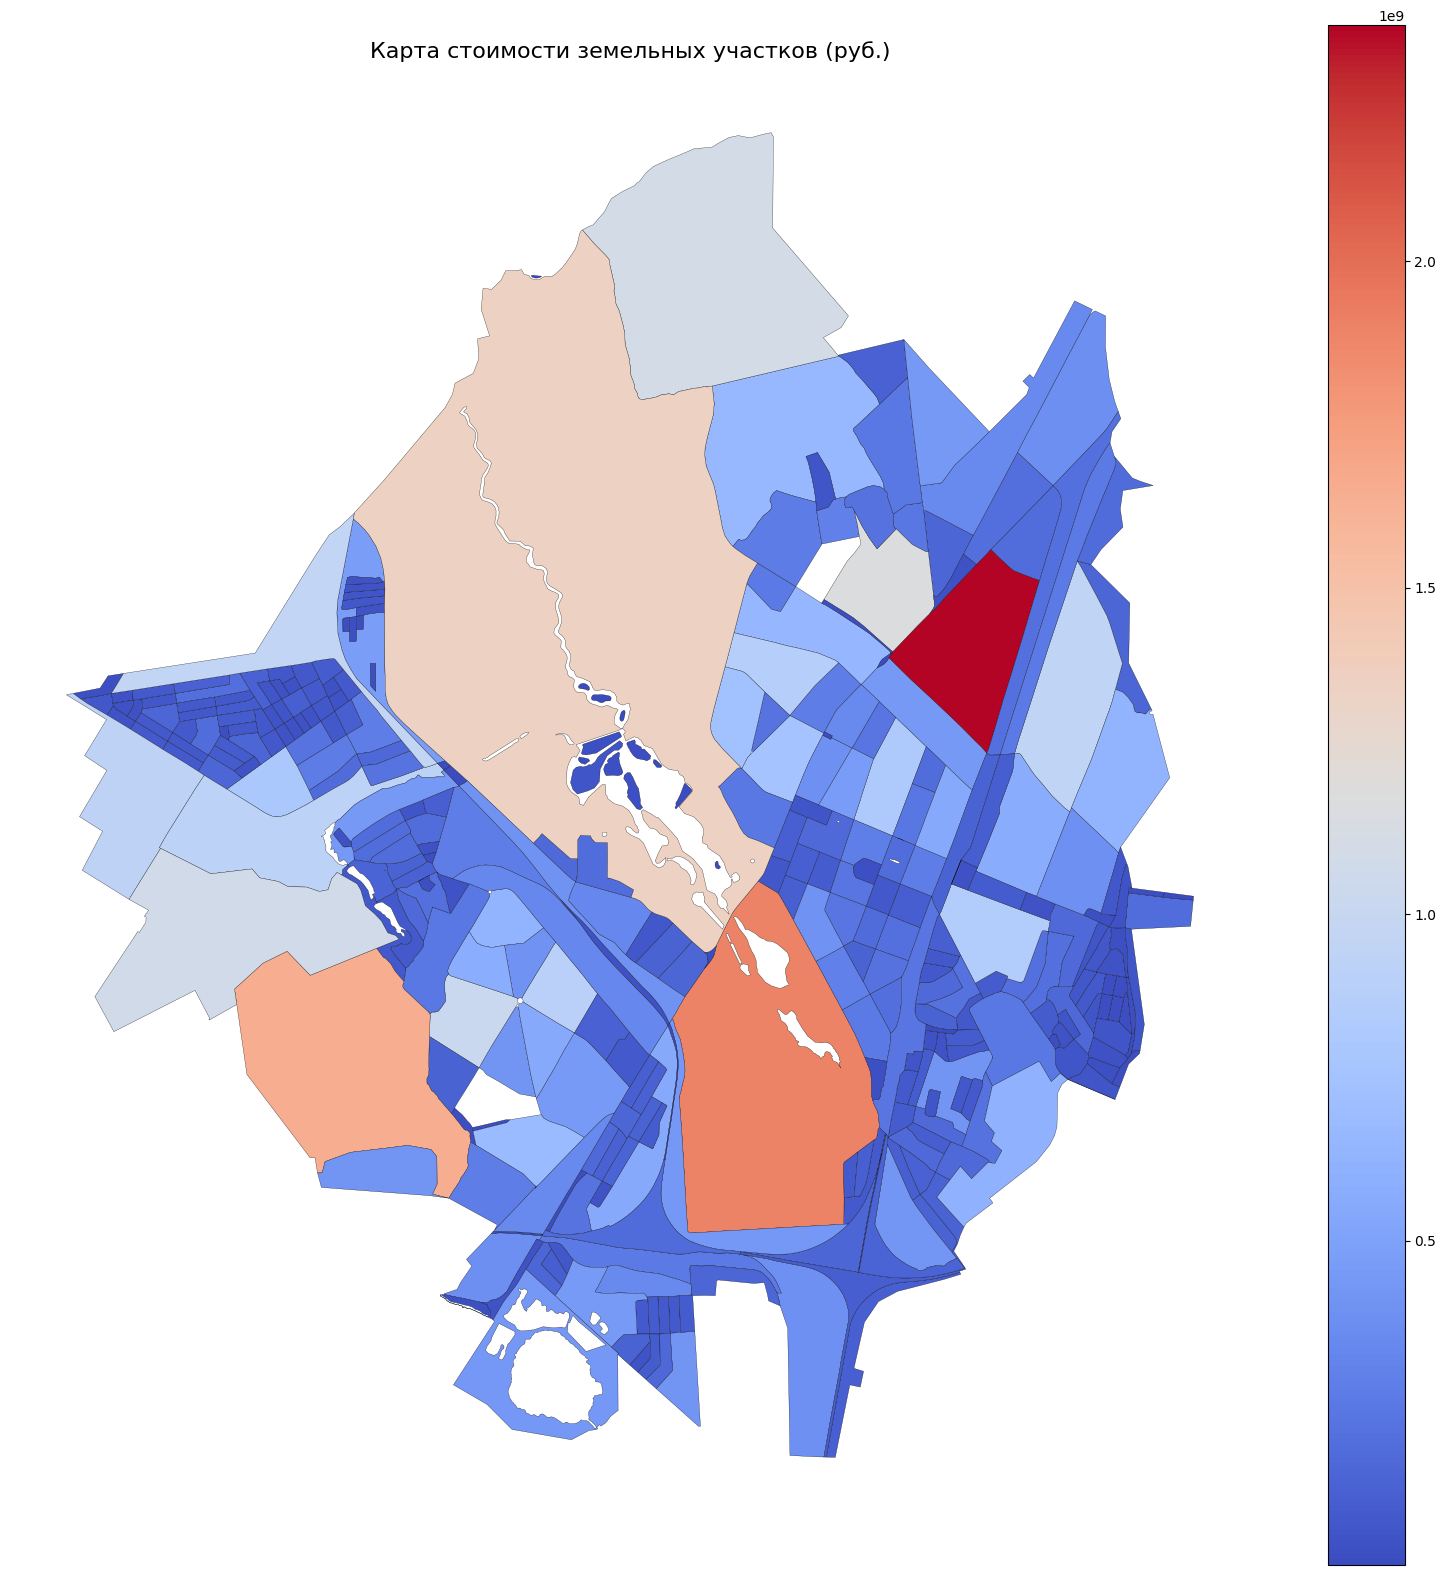

In [11]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков (руб.)', fontsize=16)

plt.show()

In [12]:
blocks_clean["id"] = blocks_clean.index

In [ ]:
# blocks_clean.to_file("./data/blocks_clean_gatchina.geojson", driver="GeoJSON")

In [14]:
target_id = 86

/var/folders/p2/g62_fg4547gdlj7_mqyl3nq80000gn/T/ipykernel_7508/2368820017.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  target_block.centroid.plot(ax=ax, color="red", markersize=30, zorder=3)


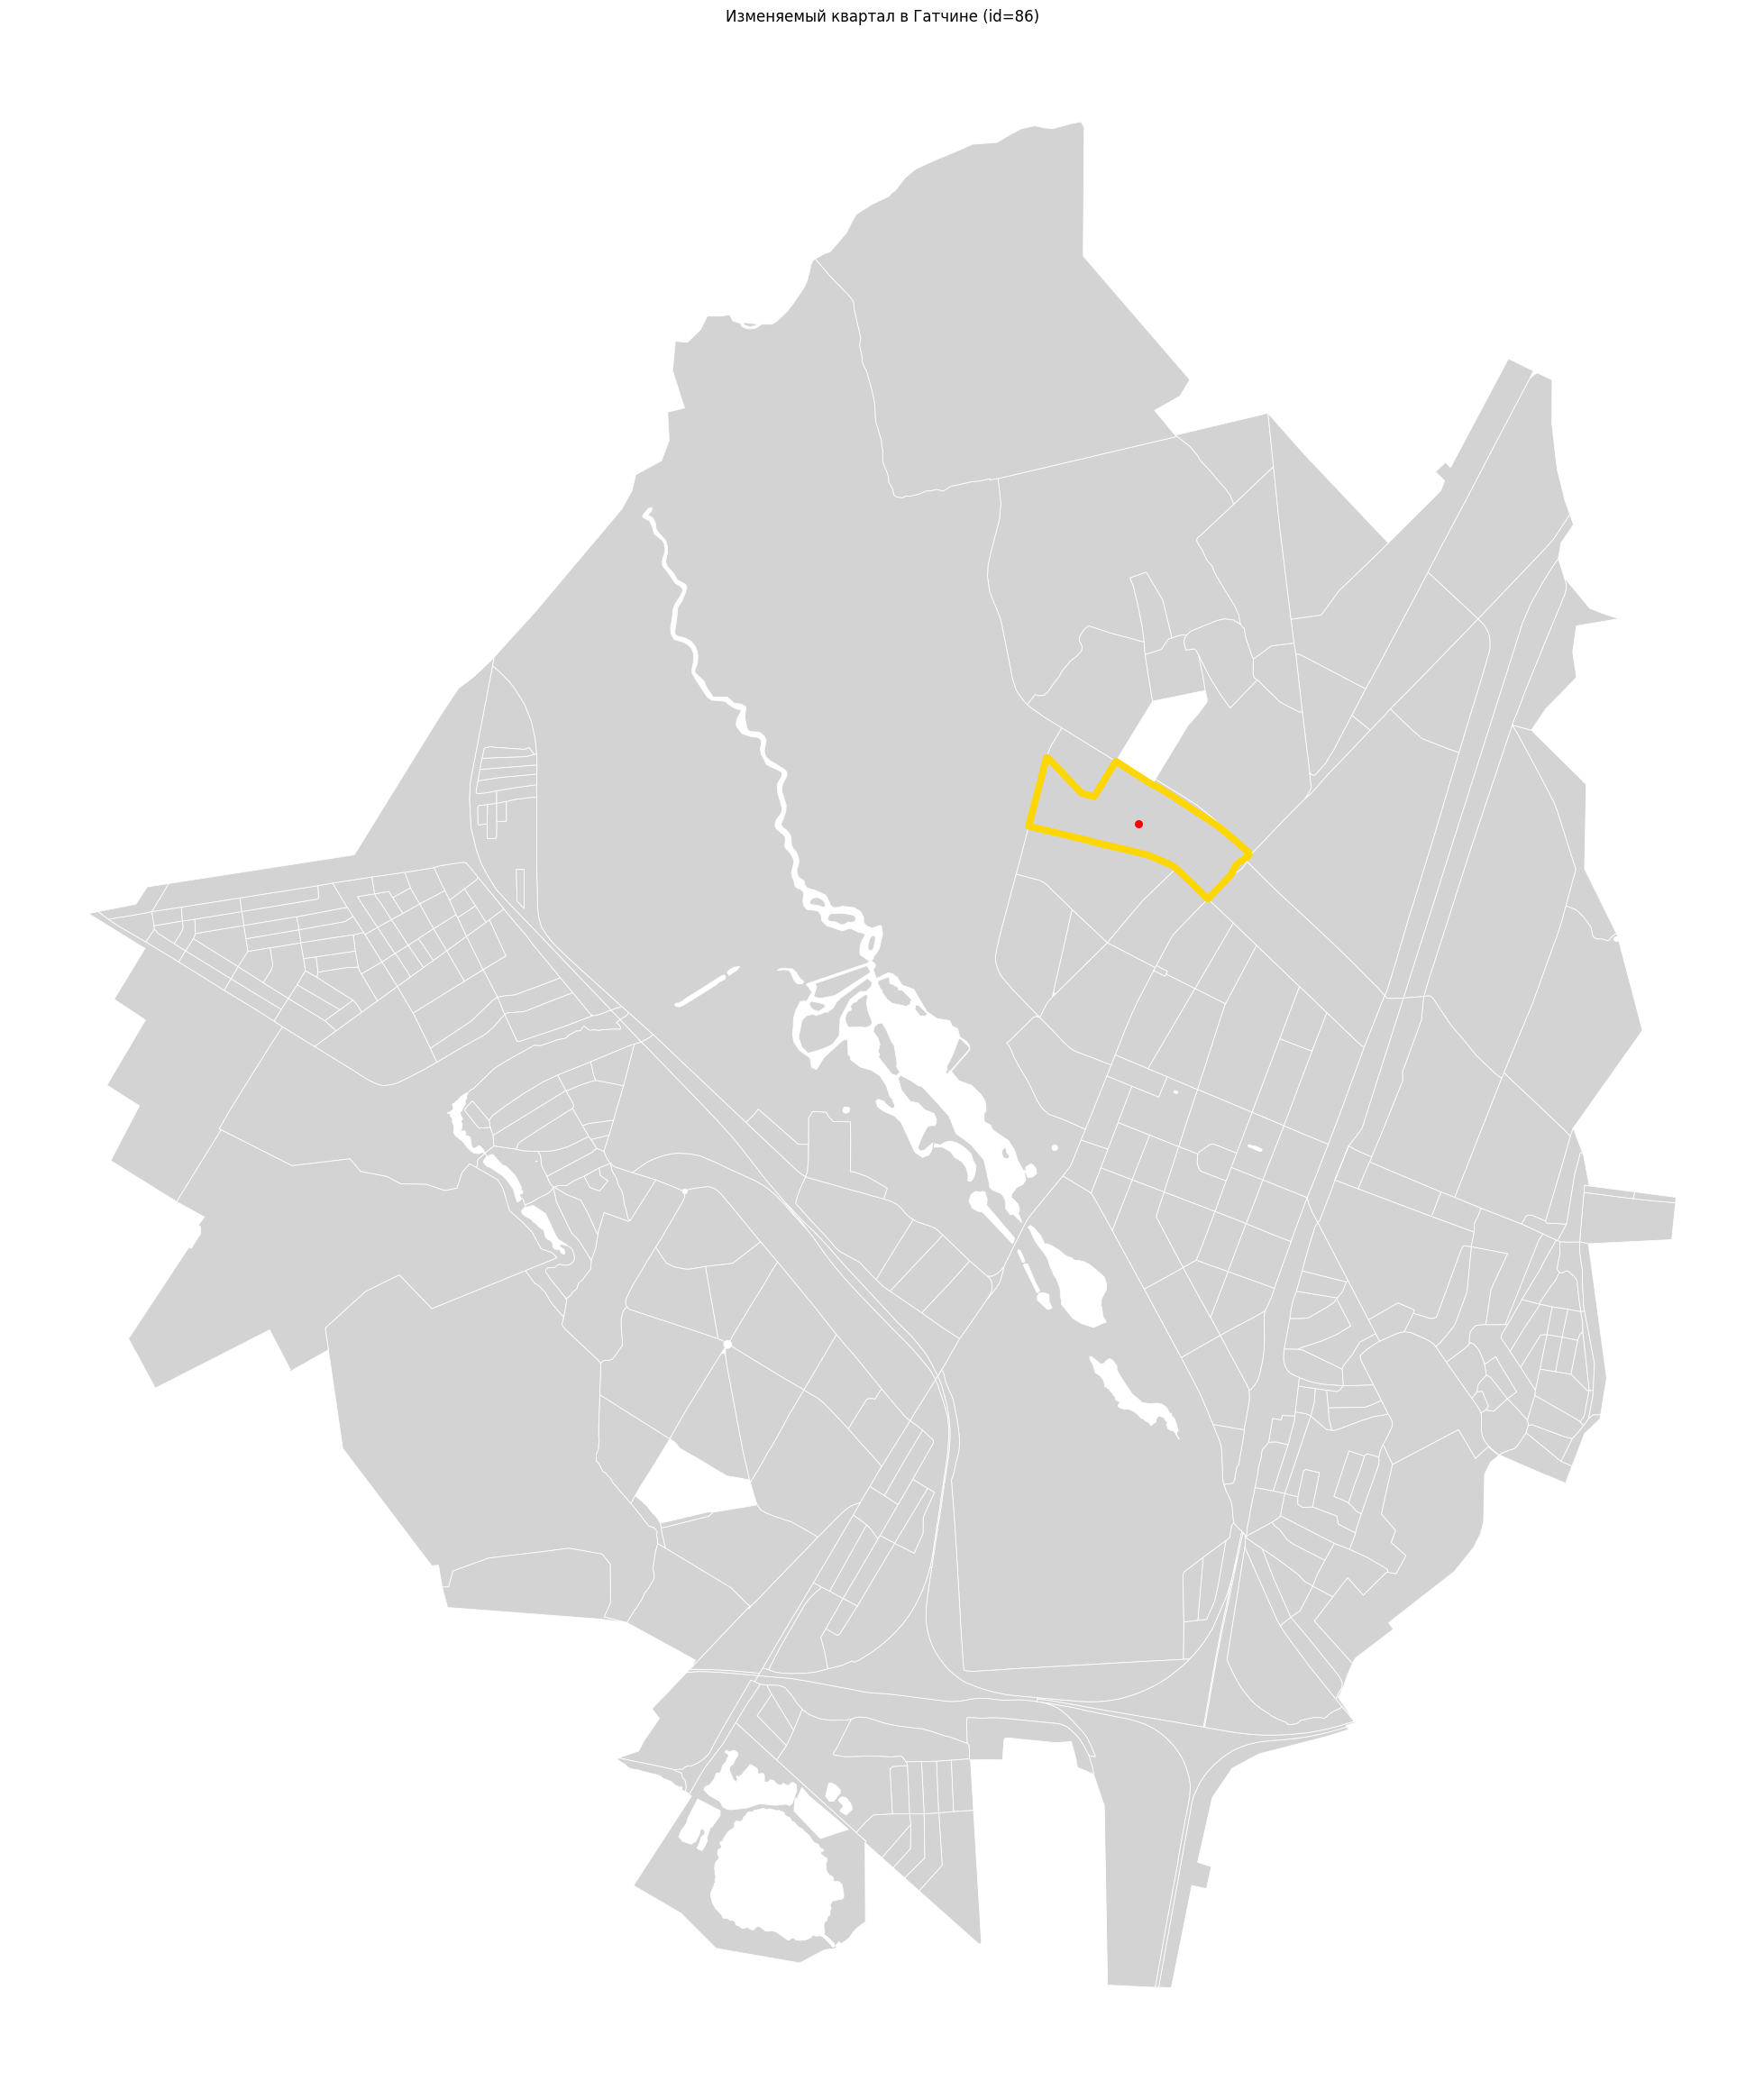

In [15]:
import matplotlib.pyplot as plt

target_id = 86
target_block = blocks_clean.loc[blocks_clean["id"] == target_id]

fig, ax = plt.subplots(figsize=(25, 35))
blocks_clean.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.6)
target_block.plot(ax=ax, color="none", edgecolor="gold", linewidth=5.5)
target_block.centroid.plot(ax=ax, color="red", markersize=30, zorder=3)

ax.set_title(f"Изменяемый квартал в Гатчине (id={target_id})")
ax.axis("off")
plt.show()


In [16]:
# blocks_after.to_file('./data/test/gatchina_RESIDENTIAL.geojson', driver='GeoJSON')

In [17]:
from blocksnet.enums import LandUse

benchmarks_ru = {
    LandUse.RESIDENTIAL: {
        "cost_build": 45_000,
        "price_sale": 140_000,
        "construction_years": 3,
        "sale_years": 4,
        "opex_rate": 800,
        "cost_demolition": 900,  # ₽/м² ориентировочно по России
    },
    LandUse.BUSINESS: {
        "cost_build": 55_000,
        "rent_annual": 25_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_300,
        "cost_demolition": 900,
    },
    LandUse.RECREATION: {
        "cost_build": 20_000,
        "rent_annual": 7_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_000,
        "cost_demolition": 900,
    },
    LandUse.SPECIAL: {
        "cost_build": 35_000,
        "rent_annual": 11_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_500,
        "cost_demolition": 900,
    },
    LandUse.INDUSTRIAL: {
        "cost_build": 38_000,
        "rent_annual": 14_800,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 700,
        "cost_demolition": 900,
    },
    LandUse.AGRICULTURE: {
        "cost_build": 25_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 300,
        "cost_demolition": 900,
    },
    LandUse.TRANSPORT: {
        "cost_build": 18_000,
        "rent_annual": 8_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 600,
        "cost_demolition": 900,
    },
}


## Оптимизация района

In [18]:
from urbanomy.methods.land_value_modeling.ga_mc_optimizer import DistrictProblem

site_area = float(blocks_clean.loc[blocks_clean["id"] == target_id, "site_area"].iloc[0])



In [19]:
problem = DistrictProblem(
    blocks=blocks_clean,
    target_id=target_id,
    model=model,
    benchmarks=benchmarks_ru,
    
constraints = {
    "footprint_area": {"type": "float", "min": 0.0, "max": 0.1 * site_area},
    "l": {"type": "float", "min": 1.0, "max": 10.0},
    "mxi": {"type": "float", "min": 0.0, "max": 1.0},

    "residential": {"type": "float", "min": 0.0, "max": 1.0},
    "business": {"type": "float", "min": 0.0, "max": 1.0},
    "recreation": {"type": "float", "min": 0.0, "max": 1.0},
    "industrial": {"type": "float", "min": 0.0, "max": 1.0},
    "transport": {"type": "float", "min": 0.0, "max": 1.0},
    "special": {"type": "float", "min": 0.0, "max": 1.0},
    "agriculture": {"type": "float", "min": 0.0, "max": 1.0},
},
    
    estimator_kwargs={
        "orig_features": numeric_feats+cat_features,
        "categorical_features": cat_features,
    }
)

In [20]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

algorithm = NSGA2(
    pop_size=20,
    eliminate_duplicates=True,
)

res = minimize(
    problem,
    algorithm,
    ('n_gen', 20),
    seed=42,
    verbose=True,
    save_history=True,
)


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       20 |      2 |             - |             -
     2 |       40 |      4 |  0.1775121713 |             f
     3 |       60 |      8 |  0.0699129747 |         ideal
     4 |       80 |      6 |  0.0748992007 |         ideal
     5 |      100 |      5 |  0.1233246757 |         ideal
     6 |      120 |      1 |  9.217860E+07 |         ideal
     7 |      140 |      3 |  1.0000000000 |         ideal
     8 |      160 |      4 |  0.3597099851 |         ideal
     9 |      180 |      5 |  0.1871886207 |         ideal
    10 |      200 |      3 |  0.8081367987 |         ideal
    11 |      220 |      3 |  0.0642896809 |         ideal
    12 |      240 |      4 |  0.1279437314 |             f
    13 |      260 |      3 |  0.4363826188 |         ideal
    14 |      280 |      8 |  0.7292785419 |         ideal
    15 |      300 |     10 |  0.0407884762 |             f
    16 |      320 |      3 |  0.8304257429 |         ide

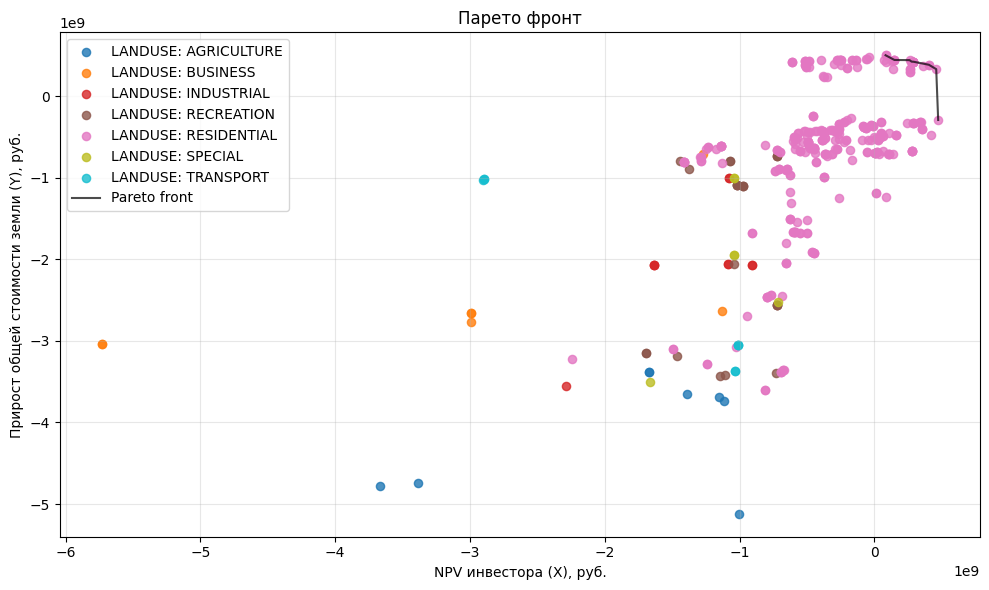

In [21]:
import numpy as np
import matplotlib.pyplot as plt

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем ВСЕ решения: из history (если optimize(..., save_history=True)), иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res, "history", None):
    for alg in res.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res.X)
    F = np.asarray(res.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]

# 4) LANDUSE для каждого решения (через тот же repair, что в оптимизаторе)
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)   # использует логику из вашей задачи
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета + легенда
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

plt.figure(figsize=(10, 6))

for lu in unique_lu:
    m = landuse_labels == lu
    plt.scatter(
        investor_npv[m],
        admin_gain[m],
        s=35,
        alpha=0.8,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# (опционально) поверх — линия самого Pareto-фронта из res.F
pf_x = -res.F[:, 1]
pf_y = -res.F[:, 0] - baseline_land_value
order = np.argsort(pf_x)
plt.plot(pf_x[order], pf_y[order], color="black", lw=1.5, alpha=0.7, label="Pareto front")

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title("Парето фронт")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()   


In [36]:
print("Лучшие решения (переменные):\n", res.X) # Массив решений на фронте Парето
print("Значения целевых функций:\n", -res.F)


Лучшие решения (переменные):
 [[1.54732704e+04 5.87666462e+00 1.07198674e-01 9.91300529e-01
  1.16598054e-01 2.65152067e-01 2.12102334e-01 2.47552847e-01
  1.39171530e-01 7.25385496e-04]
 [1.54732704e+04 5.87666462e+00 1.07198674e-01 9.91300529e-01
  1.15120646e-01 2.65152067e-01 2.12102334e-01 2.47552847e-01
  1.39171530e-01 7.25385496e-04]
 [1.54389749e+04 5.43160845e+00 1.38498532e-01 9.88742074e-01
  1.09212586e-01 2.66720785e-01 2.11818266e-01 2.18734946e-01
  4.38149548e-02 7.25385496e-04]
 [1.61306906e+04 5.43335224e+00 6.65096023e-02 8.86546067e-01
  1.32542070e-01 2.66845192e-01 2.11853689e-01 2.48346152e-01
  1.43670993e-01 5.32630591e-04]
 [1.18376520e+04 5.87670560e+00 1.37537981e-01 9.88843755e-01
  1.31941349e-01 2.53153711e-01 1.82005445e-01 1.94934180e-01
  1.32558284e-01 6.14730897e-04]
 [1.59470523e+04 5.89307842e+00 9.25391872e-02 9.91252812e-01
  1.26016524e-01 2.53375954e-01 1.17735507e-01 2.18437070e-01
  1.58332273e-01 1.02766240e-04]
 [1.54732704e+04 5.87666495e

In [23]:
len(res.opt)

9

In [24]:
import numpy as np

# т.к. F минимизируется, а ты пишешь F[:,0] = -land_value
idx_city = np.argmin(res.F[:, 0])   # максимум land_value
params_optimal = {p: res.X[idx_city][i] for i, p in enumerate(problem.constraints.keys())}
params_optimal

{'footprint_area': np.float64(16130.69055777145),
 'l': np.float64(5.433352239782216),
 'mxi': np.float64(0.0665096023076514),
 'residential': np.float64(0.8865460665772719),
 'business': np.float64(0.1325420696032599),
 'recreation': np.float64(0.26684519195498185),
 'industrial': np.float64(0.21185368882868205),
 'transport': np.float64(0.24834615207850907),
 'special': np.float64(0.14367099338181036),
 'agriculture': np.float64(0.0005326305913425707)}

In [46]:
params_optimal = {param: res.X[4][i] for i, param in enumerate(problem.constraints.keys())}
params_optimal

{'footprint_area': np.float64(11837.651977125355),
 'l': np.float64(5.8767055962839265),
 'mxi': np.float64(0.1375379812412612),
 'residential': np.float64(0.988843754969788),
 'business': np.float64(0.1319413493104758),
 'recreation': np.float64(0.25315371094971584),
 'industrial': np.float64(0.1820054446710271),
 'transport': np.float64(0.1949341800761677),
 'special': np.float64(0.13255828411003712),
 'agriculture': np.float64(0.0006147308972732856)}

In [47]:
params_repaired = problem._repair_genome(params_optimal)
params_repaired

{'footprint_area': 11837.651977125355,
 'l': 5.8767055962839265,
 'mxi': 0.1375379812412612,
 'residential': 0.5248496543731239,
 'business': 0.07003065068175769,
 'recreation': 0.13436666513537474,
 'industrial': 0.09660322396689847,
 'transport': 0.10346542264567449,
 'special': 0.0703581018232481,
 'agriculture': 0.0003262813739226394,
 'share': 0.5248496543731239,
 'land_use': <LandUse.RESIDENTIAL: 'residential'>,
 'build_floor_area': 69566.39562083407,
 'living_area': 9568.021615920432,
 'non_living_area': 59998.37400491364,
 'population': 478.4010807960216,
 'fsi': 0.2652664851041709,
 'gsi': 0.045138637755124125,
 'morphotype': 'mid-rise non-residential'}

Изменение стоимости земли по всем кварталам:
 • Сумма до:    62 951 519 914 ₽
 • Сумма после: 63 334 134 963 ₽
 • Изм.  ₽:     +382 615 049 ₽
 • Изм., %:     +0.61%

Изменяемый квартал:
 • До: 590 959 314 ₽ | После: 693 587 953 ₽ | Δ: +102 628 639 ₽ | Δ%: +17.37%


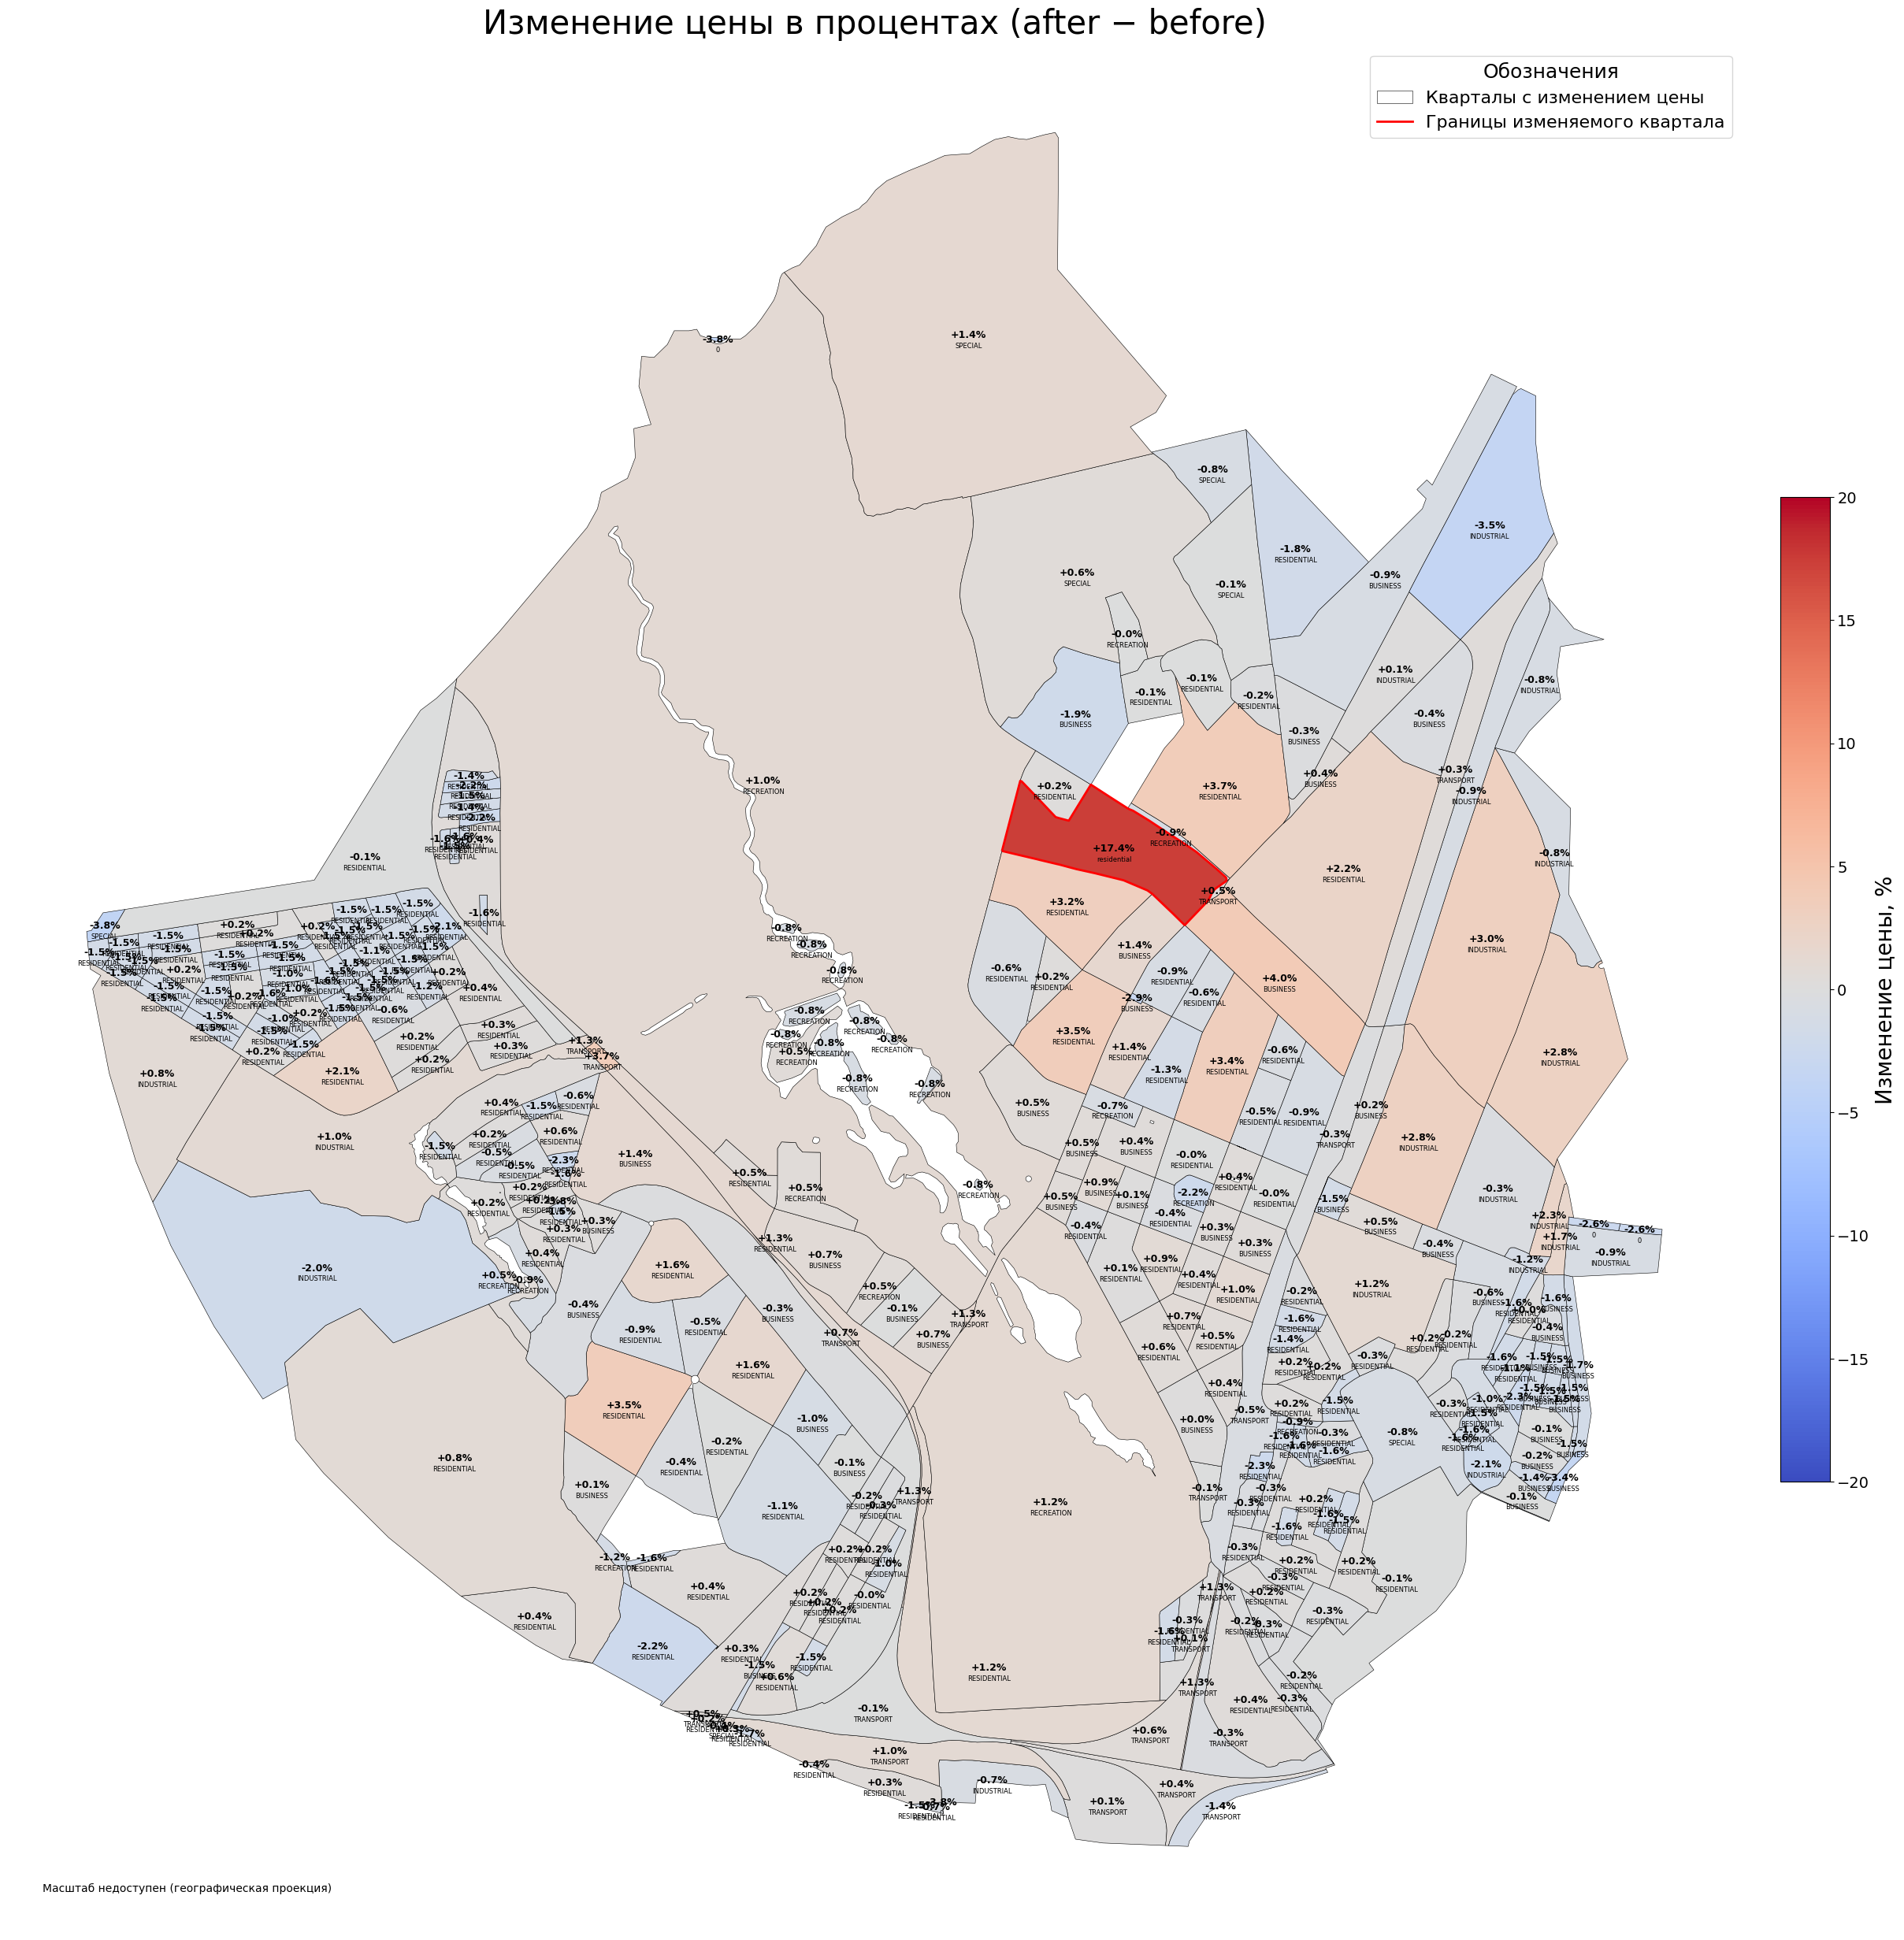

In [45]:
import numpy as np
import pandas as pd

from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    LandPriceEstimator,
    plot_scenario_impact,
)


# Базовые кварталы должны быть теми же, что использовал оптимизатор
blocks_before = problem.blocks.copy()

# Помечаем проектный квартал
blocks_before["is_project"] = False
blocks_before.loc[blocks_before["id"] == target_id, "is_project"] = True

# 1) Применяем оптимизационный сценарий к базовым кварталам
modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_id, params_repaired)
blocks_after["is_project"] = False
blocks_after.loc[blocks_after["id"] == target_id, "is_project"] = True

# 2) Считаем стоимость "до" и "после" тем же способом, что и в DistrictProblem
estimator_kwargs = dict(
    model=problem.model,
    orig_features=problem.estimator_kwargs["orig_features"],
    categorical_features=problem.estimator_kwargs["categorical_features"],
    use_service_features=False,
)

baseline_estimator = LandPriceEstimator(
    blocks=blocks_before,
    **estimator_kwargs,
)
blocks_before_pred = baseline_estimator.predict()

scenario_estimator = LandPriceEstimator(
    blocks=blocks_after,
    **estimator_kwargs,
)
blocks_after_pred = scenario_estimator.predict()

for df in (blocks_before_pred, blocks_after_pred):
    df["land_value_per_100m2"] = np.where(
        pd.to_numeric(df["site_area"], errors="coerce") > 0,
        pd.to_numeric(df["land_value"], errors="coerce")
        / pd.to_numeric(df["site_area"], errors="coerce") * 100,
        np.nan,
    )

baseline_cols = blocks_before_pred[
    ["id", "land_value", "land_value_per_100m2"]
].rename(
    columns={
        "land_value": "land_value_before",
        "land_value_per_100m2": "land_value_before_per_100m2",
    }
)

blocks_full_value = blocks_after_pred.merge(
    baseline_cols,
    on="id",
    how="left",
    validate="one_to_one",
)

blocks_full_value["d_rub"] = (
    blocks_full_value["land_value"] - blocks_full_value["land_value_before"]
)

blocks_full_value["land_value_delta_pct"] = np.where(
    pd.to_numeric(blocks_full_value["land_value_before"], errors="coerce") > 0,
    (blocks_full_value["land_value"] / blocks_full_value["land_value_before"] - 1.0) * 100,
    np.nan,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)

sum_before = float(blocks_full_value["land_value_before"].sum())
sum_after = float(blocks_full_value["land_value"].sum())
sum_delta = sum_after - sum_before
sum_delta_pct = (sum_after / sum_before - 1.0) * 100 if sum_before > 0 else np.nan

print("Изменение стоимости земли по всем кварталам:")
print(f" • Сумма до:    {sum_before:,.0f} ₽".replace(",", " "))
print(f" • Сумма после: {sum_after:,.0f} ₽".replace(",", " "))
print(f" • Изм., ₽:     {sum_delta:+,.0f} ₽".replace(",", " "))
print(f" • Изм., %:     {sum_delta_pct:+.2f}%")

target_row = blocks_full_value.loc[blocks_full_value["id"] == target_id].iloc[0]
print("\nИзменяемый квартал:")
print(
    f" • До: {target_row['land_value_before']:,.0f} ₽ | "
    f"После: {target_row['land_value']:,.0f} ₽ | "
    f"Δ: {target_row['d_rub']:+,.0f} ₽ | "
    f"Δ%: {target_row['land_value_delta_pct']:+.2f}%".replace(",", " ")
)

scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_id,
    target_id_column="id",
    print_summary=False,
    print_quarter_stats=False,
    figsize=(25, 35),
)



In [40]:
import pandas as pd

blocks_gen = modifier.apply(target_id, params_repaired)   # без запятой

gen_blocks = pd.DataFrame(blocks_gen)

gen_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,morphotype,area_accessibility,geometry,site_area,land_value,land_value_per_100m2,id,is_project,share_living,share_non_living
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",215420.389645,4.523965e+08,210006.365794,0,False,NaN,NaN
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",108166.972589,6.273598e+08,579991.970625,1,False,NaN,NaN
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",32058.270586,1.065881e+08,332482.363541,3,False,NaN,NaN
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",30779.356283,8.802486e+07,285986.682700,4,False,NaN,NaN
5,0.262580,0.000000,0.000186,0.0,0.737236,0.0,0.0,LandUse.TRANSPORT,0.737236,1946.641824,...,individual residential,10.294833,"POLYGON ((30.13162 59.55046, 30.1319 59.55029,...",37909.234921,8.177854e+07,215721.956498,5,False,NaN,NaN


In [41]:
gen_blocks.loc[gen_blocks["id"] == 86].iloc[0]

residential                                                      0.537427
business                                                         0.059362
recreation                                                       0.144975
industrial                                                       0.115133
transport                                                        0.118893
special                                                          0.023815
agriculture                                                      0.000394
land_use                                              LandUse.RESIDENTIAL
share                                                            0.537427
footprint_area                                               15438.974877
build_floor_area                                             83858.466469
living_area                                                  11614.274521
non_living_area                                              72244.191948
population                            

In [42]:
blocks_before.loc[blocks_before["id"] == 86].iloc[0]

residential                                                      0.268468
business                                                         0.648297
recreation                                                       0.065871
industrial                                                            0.0
transport                                                         0.01739
special                                                               0.0
agriculture                                                           0.0
land_use                                                 LandUse.BUSINESS
share                                                            0.648297
footprint_area                                               47096.975151
build_floor_area                                            107107.690178
living_area                                                  44241.785252
non_living_area                                              62865.904925
population                            

In [43]:
from urbanomy.methods.investment_potential import prepare_investment_input

investment_input = prepare_investment_input(
    gdf = gen_blocks
)

investment_input.head()


2026-03-13 17:08:35.716 | WARNING  | urbanomy.utils.investment_input:prepare_investment_input:265 - prepare_investment_input: колонка 'land_value_before' не найдена; значения скопированы из 'land_value'.


,land_use,land_value,land_value_before,residential,business,recreation,industrial,transport,special,agriculture,site_area,living_area,non_living_area,build_floor_area,share
0,LandUse.RESIDENTIAL,6.519223e+08,6.519223e+08,140940.834372,15567.77391,38019.87495,30193.762288,31179.704626,6245.62912,103.400512,262250.979778,11614.274521,72244.191948,83858.466469,0.537427


In [44]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_ru)
summary = an.calculate_investment_metrics(investment_input, discount_rate=0.18)
summary

Project totals:
 • Land area:          262,250.98
 • Built area:         83,858.47
 • Land value:         651,922,266.23
 • Demolition cost:    75,472,619.82
 • Construction cost:  3,162,065,456.14
 • Investment need:    3,889,460,342.18
 • Project NPV:        404,737,841.02
 • Project IRR:        0.21
 • Project PI:         1.12
 • Project PP (yrs):   6.95


,land_use,land_area,land_value_before,built_area,land_value,demolition_cost,construction_cost,investment_need,NPV,IRR,PI,PP_years,EI
0,LandUse.RESIDENTIAL,262250.98,6.519223e+08,83858.47,6.519223e+08,75472619.82,3.162065e+09,3.889460e+09,4.047378e+08,0.21,1.12,6.95,62.06


In [33]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model='gpt-oss:120b',
    base_url="http://a.dgx:11434/",
    temperature=0.0
)


In [49]:
from urbanomy.methods.land_value_modeling import (
    select_best_pareto_scenario_multiagent,
)

baseline_land_value = problem.evaluate_catboost(
    geonome=problem.blocks,
    model=problem.model,
    orig_features=problem.estimator_kwargs["orig_features"],
    cat_features=problem.estimator_kwargs["categorical_features"],
    radius_list=None,
)

selection = select_best_pareto_scenario_multiagent(
    problem=problem,
    res=res,
    llm=llm,
    baseline_land_value=baseline_land_value,
    selection_goal=(
        "Выбери лучший сценарий развития территории. "
        "Сначала рассматривай сценарии с положительным NPV инвестора "
        "и положительным приростом суммарной стоимости всей земли. "
        "Также учитывай предполагаемую значимость сценария для города."
    ),
)

print("Выбранный сценарий:", selection["selected_scenario_id"])
print("Почему:", selection["reason"])
print("Мнение жителей:", selection["agent_opinions"]["resident"])
print("Мнение инвестора:", selection["agent_opinions"]["investor"])
print("Мнение администрации:", selection["agent_opinions"]["administrator"])
selection["best_scenario"]["params_repaired"]



Выбранный сценарий: 7
Почему: Сценарий 7 обеспечивает хороший NPV инвестора, высокий прирост доходов администрации и значительный рост стоимости земли, при сбалансированном распределении жилых, бизнес‑ и рекреационных функций, что делает его оптимальным компромиссом для инвесторов, жителей и города.
Мнение жителей: {'preferred_scenario_id': 5, 'reason': 'Сценарий 5 сочетает высокий жилой удельный вес (≈53\u202f%), низкую долю промышленности (≈6\u202f%), хорошее покрытие бизнес‑ и культурных функций, умеренную плотность (FSI\u202f≈\u202f0.36) и достаточное количество населения, что обеспечивает комфортную, разнообразную и живую городскую среду для жителей.'}
Мнение инвестора: {'preferred_scenario_id': 2, 'reason': 'Сценарий 2 сочетает высокий NPV инвестора (≈405\u202fмлн\u202f$), значительный прирост доходов администрации (≈383\u202fмлн\u202f$) и хорошую динамику стоимости земли (≈0,61\u202f% роста), при умеренной плотности и устойчивой структуре использования территории.'}
Мнение админ

{'footprint_area': 15473.270415813331,
 'l': 6.286981515813765,
 'mxi': 0.10283118216499165,
 'residential': 0.485139563942275,
 'business': 0.10693997977034138,
 'recreation': 0.12410339670057255,
 'industrial': 0.09286325958847376,
 'transport': 0.12233046794703303,
 'special': 0.06811013736449338,
 'agriculture': 0.0005131946868110616,
 'share': 0.485139563942275,
 'land_use': 'RESIDENTIAL',
 'build_floor_area': 97280.16509340638,
 'living_area': 10003.434377760534,
 'non_living_area': 87276.73071564584,
 'population': 500.1717188880267,
 'fsi': 0.37094299962485217,
 'gsi': 0.05900176399307237,
 'morphotype': 'mid-rise non-residential'}

In [35]:
selection["candidate_scenarios"]

[{'scenario_id': 0,
  'objectives': {'land_value_total': 63371434088.9626,
   'investor_npv': 288513366.84,
   'admin_gain_vs_baseline': 419914175.2736664,
   'land_value_growth_total_pct': 0.667043743899113},
  'params_raw': {'footprint_area': 15473.270415813331,
   'l': 5.8766646188293254,
   'mxi': 0.10719867391141454,
   'residential': 0.9913005287104544,
   'business': 0.11659805374930104,
   'recreation': 0.265152066965287,
   'industrial': 0.2121023342048985,
   'transport': 0.24755284682789497,
   'special': 0.1391715295930753,
   'agriculture': 0.000725385496289168},
  'params_repaired': {'footprint_area': 15473.270415813331,
   'l': 5.8766646188293254,
   'mxi': 0.10719867391141454,
   'residential': 0.502534294321621,
   'business': 0.05910873540681235,
   'recreation': 0.13441736688434638,
   'industrial': 0.10752409966156733,
   'transport': 0.12549554003546912,
   'special': 0.07055223354384468,
   'agriculture': 0.0003677301463391941,
   'share': 0.502534294321621,
   'l